# **SIGK Denoising**

### Import Dataset DIV2K

In [176]:
import os
from typing import Any, Tuple
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms


class ImageDataset(Dataset):
    def __init__(self, root: str, noise_level: float = None, input_size: Tuple[int, int] = None):
        self.root = root
        self.image_paths = [
            os.path.join(root, f) for f in os.listdir(root) if f.endswith(".png")
        ]
        self.transform = transforms.ToTensor()
        if noise_level and input_size:
            raise ValueError("Only one value can be set at the same time.")
        self.noise_level = noise_level
        self.input_size = input_size

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.__resize(img, (256, 256))
        if self.input_size is not None:
            modified_img = self.__resize(img, self.input_size)
            modified_img = modified_img.astype(np.float32) / 255.0
            modified_img = self.transform(modified_img)

        img = img.astype(np.float32) / 255.0
        img = self.transform(img)

        if self.noise_level is not None:
            modified_img = self.__add_noise(img, self.noise_level)

        return modified_img, img

    def __add_noise(self, img: torch.Tensor, noise_level: float = 0.1) -> torch.Tensor:
        noise = torch.randn_like(img) * noise_level
        noisy_img = img + noise
        noisy_img = torch.clamp(noisy_img, 0.0, 1.0)
        return noisy_img

    def __resize(self, img: Any, size: Tuple[int, int]) -> Any:
        img = cv2.resize(img, size)
        return img

In [177]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [178]:
%env DATASET_PATH=/content/drive/MyDrive/SIGK

env: DATASET_PATH=/content/drive/MyDrive/SIGK


In [179]:
from torch.utils.data import DataLoader

noise = 0.1

train_dataset = ImageDataset(f"{os.getenv('DATASET_PATH')}/DIV2K_train_HR", noise)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=False, num_workers=0)

valdiation_dataset = ImageDataset(f"{os.getenv('DATASET_PATH')}/DIV2K_valid_HR", noise)
valdiation_dataloader = DataLoader(valdiation_dataset, batch_size=16, shuffle=False, num_workers=0)

Example dataset images

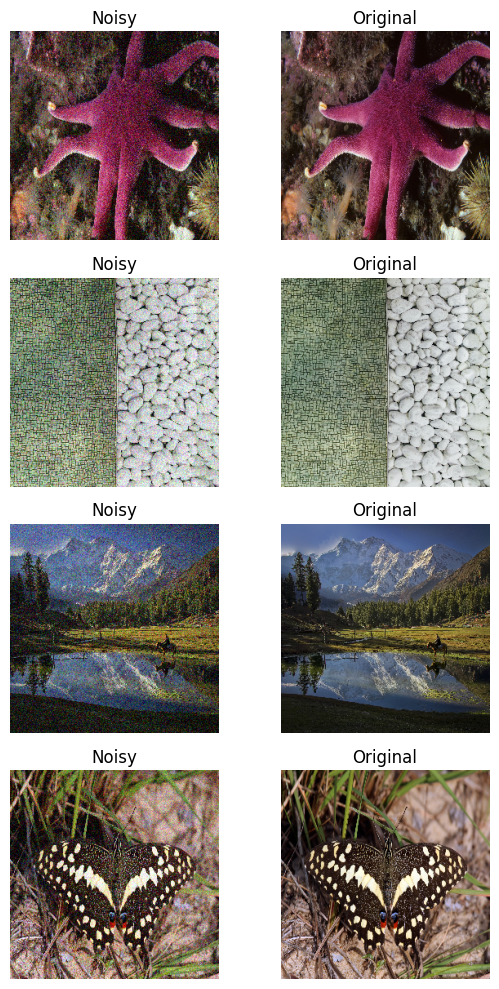

In [180]:
import matplotlib.pyplot as plt

x, y = next(iter(train_dataloader))

num_samples = 4
fig, axs = plt.subplots(num_samples, 2, figsize=(6, 10))

for i in range(num_samples):
    axs[i, 0].imshow(x[i].permute(1, 2, 0))
    axs[i, 0].set_title("Noisy")
    axs[i, 0].axis("off")

    axs[i, 1].imshow(y[i].permute(1, 2, 0))
    axs[i, 1].set_title("Original")
    axs[i, 1].axis("off")

plt.tight_layout()
plt.show()

### Denoising model UNET


In [181]:
import torch
import torch.nn as nn
from typing import Optional

class UNet(nn.Module):

    def __init__(
        self,
        in_channels: int = 3,
        out_channels: int = None,
        init_features: int = 64,
        use_bnorm: bool = True,
    ):
        super(UNet, self).__init__()

        if out_channels is None:
            out_channels = in_channels

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.init_features = init_features
        self.use_bnorm = use_bnorm

        features = init_features

        self.encoder1 = self._make_layer(in_channels, features, use_bnorm)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder2 = self._make_layer(features, features * 2, use_bnorm)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder3 = self._make_layer(features * 2, features * 4, use_bnorm)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder4 = self._make_layer(features * 4, features * 8, use_bnorm)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = self._make_layer(features * 8, features * 16, use_bnorm)

        self.upconv4 = nn.ConvTranspose2d(features * 16, features * 8, kernel_size=2, stride=2)
        self.decoder4 = self._make_layer(features * 16, features * 8, use_bnorm)

        self.upconv3 = nn.ConvTranspose2d(features * 8, features * 4, kernel_size=2, stride=2)
        self.decoder3 = self._make_layer(features * 8, features * 4, use_bnorm)

        self.upconv2 = nn.ConvTranspose2d(features * 4, features * 2, kernel_size=2, stride=2)
        self.decoder2 = self._make_layer(features * 4, features * 2, use_bnorm)

        self.upconv1 = nn.ConvTranspose2d(features * 2, features, kernel_size=2, stride=2)
        self.decoder1 = self._make_layer(features * 2, features, use_bnorm)

        self.conv_out = nn.Conv2d(features, out_channels, kernel_size=1)

    def _make_layer(self, in_channels: int, out_channels: int, use_bnorm: bool):
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_bnorm),
            nn.BatchNorm2d(out_channels) if use_bnorm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_bnorm),
            nn.BatchNorm2d(out_channels) if use_bnorm else nn.Identity(),
            nn.ReLU(inplace=True)
        ]
        return nn.Sequential(*layers)

    def forward(self, x):

        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))
        enc4 = self.encoder4(self.pool3(enc3))

        bottleneck = self.bottleneck(self.pool4(enc4))

        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat([dec4, enc4], dim=1)
        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.decoder1(dec1)

        output = self.conv_out(dec1)

        return output

UNET loss functions

In [182]:
"""
Loss functions for image denoising
Includes Perceptual Loss and Charbonnier Loss
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vgg16


class CharbonnierLoss(nn.Module):

    def __init__(self, epsilon: float = 1e-3, reduction: str = 'mean'):
        super(CharbonnierLoss, self).__init__()
        self.epsilon = epsilon
        self.reduction = reduction

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        diff = pred - target
        loss = torch.sqrt(diff * diff + self.epsilon * self.epsilon)

        return torch.mean(loss)


class PerceptualLoss(nn.Module):
    def __init__(self):
        super(PerceptualLoss, self).__init__()
        vgg = vgg16(pretrained=True).features[:16]
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg.eval()

    def forward(self, denoised, gt):
        denoised_features = self.vgg(denoised)
        gt_features = self.vgg(gt)
        loss = F.mse_loss(denoised_features, gt_features)
        return loss


class CombinedLoss(nn.Module):

    def __init__(
        self,
        charbonnier_loss: nn.Module,
        perceptual_loss: nn.Module,
        mse_weight: float = 1.0,
        charbonnier_weight: float = 1.0,
        perceptual_weight: float = 0.1
    ):
        super(CombinedLoss, self).__init__()
        self.mse_weight = mse_weight
        self.charbonnier_loss = charbonnier_loss
        self.perceptual_loss = perceptual_loss
        self.charbonnier_weight = charbonnier_weight
        self.perceptual_weight = perceptual_weight

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        mse_loss = nn.MSELoss()(pred, target)
        loss = self.charbonnier_weight * self.charbonnier_loss(pred, target)
        loss += mse_loss * self.mse_weight
        if self.perceptual_loss is not None:
            loss += self.perceptual_weight * self.perceptual_loss(pred, target)

        return loss


def get_charbonnier_loss() -> CharbonnierLoss:
    return CharbonnierLoss()



In [183]:
import torch
import time
from tqdm import tqdm
import random
import numpy as np

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_epoch(model, loader, criterion, optimizer, device, epoch=None):
    model.train()
    total_loss = 0
    start_time = time.time()

    for batch_idx, (x, y) in tqdm(enumerate(loader)):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}/{len(loader)}, "
                       f"Batch Loss: {loss.item():.6f}")

    avg_loss = total_loss / len(loader)
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch} Training - Avg Loss: {avg_loss:.6f}, "
                   f"Time: {epoch_time:.2f}s")

    return avg_loss

def validate(model, loader, criterion, device, epoch=None):
    model.eval()
    total_loss = 0
    batch_count = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()
            batch_count += 1

    avg_loss = total_loss / batch_count
    print(f"Epoch {epoch} Validation - Loss: {avg_loss:.6f}")

    return avg_loss

UNET Training function

In [184]:
import torch
from torch.utils.data import DataLoader
import time
from datetime import datetime


def train_model(data, model, device, epochs=7):
    train_loader = data

    criterion = CombinedLoss(
        charbonnier_loss=CharbonnierLoss(),
        perceptual_loss=PerceptualLoss().to(device),
        mse_weight=1.0,
        charbonnier_weight=0.5,
        perceptual_weight=0.1
    ).to(device)

    print("Loss Configuration:")
    print("Combined Loss: MSE(1.0) + Charbonnier(0.5) + Perceptual(0.1)")

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-5
    )

    print("Optimizer: Adam, LR: 1e-4, Weight Decay: 1e-5")
    print("-" * 80)

    best_val_loss = float("inf")
    training_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()
        print(f"Starting Epoch {epoch + 1}/{epochs}")

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, epoch + 1)

        epoch_time = time.time() - epoch_start_time
        total_time = time.time() - training_start_time

        print(f"Epoch {epoch + 1} Summary:")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Epoch Time: {epoch_time:.2f}s")
        print(f"  Total Time: {total_time:.2f}s")
        print(f"  Estimated remaining: {(total_time / (epoch + 1) * (epochs - epoch - 1)):.2f}s")

        print("-" * 40)

    total_training_time = time.time() - training_start_time
    print(f"Best validation loss: {best_val_loss:.6f}")
    model_filename = "best_model_unet_init"
    model_filename += ".pth"
    torch.save(model.state_dict(), model_filename)
    print(f"Final model saved as: {model_filename}")

    print("="*80)
    print("TRAINING COMPLETED")
    print(f"Total training time: {total_training_time:.2f}s ({total_training_time/60:.1f} min)")
    print(f"Average time per epoch: {total_training_time/epochs:.2f}s")
    print(f"Best validation loss: {best_val_loss:.6f}")
    print(f"Final model saved as: {model_filename}")

    return best_val_loss

# Training UNET model

In [185]:
epochs = 7

print("="*80)
print("U-Net Training Experiment")
print(f"Epochs: {epochs}")
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("="*80)

set_seed(42)

print(f"Total images found: {len(train_dataset)}")


print("Starting training...")
experiment_start_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(
    in_channels=3,
    init_features=128,
    use_bnorm=True,
).to(device)

best_training_loss = train_model(train_dataloader, model, device, epochs)

experiment_total_time = time.time() - experiment_start_time

print("="*80)
print("EXPERIMENT COMPLETED")
print(f"Total experiment time: {experiment_total_time:.2f}s ({experiment_total_time/60:.1f} min)")
print(f"Best training loss: {best_training_loss:.6f}")
print(f"End Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

U-Net Training Experiment
Epochs: 7
Start Time: 2025-11-02 17:08:43
Total images found: 800
Starting training...
Loss Configuration:
Combined Loss: MSE(1.0) + Charbonnier(0.5) + Perceptual(0.1)
Optimizer: Adam, LR: 1e-4, Weight Decay: 1e-5
--------------------------------------------------------------------------------
Starting Epoch 1/7


1it [00:03,  3.04s/it]

Epoch 1, Batch 0/50, Batch Loss: 1.068527


11it [00:32,  2.90s/it]

Epoch 1, Batch 10/50, Batch Loss: 0.599720


...

Epoch 7, Batch 30/50, Batch Loss: 0.134667


41it [01:59,  2.95s/it]

Epoch 7, Batch 40/50, Batch Loss: 0.143612


50it [02:26,  2.93s/it]


Epoch 7 Training - Avg Loss: 0.139136, Time: 146.34s
Epoch 7 Summary:
  Train Loss: 0.139136
  Epoch Time: 146.34s
  Total Time: 1023.68s
  Estimated remaining: 0.00s
----------------------------------------
Best validation loss: inf
Final model saved as: best_model_unet_init.pth
TRAINING COMPLETED
Total training time: 1023.68s (17.1 min)
Average time per epoch: 146.24s
Best validation loss: inf
Final model saved as: best_model_unet_init.pth
EXPERIMENT COMPLETED
Total experiment time: 1027.07s (17.1 min)
Best training loss: inf
End Time: 2025-11-02 17:25:50


In [186]:
def denoise_image(model, image, device):
    model.eval()
    with torch.no_grad():
        noisy_image = image.to(device)
        denoised = model(noisy_image)

    return denoised

def visualize_image(original, noisy, denoised, n=4):

    original = original.permute(0, 2, 3, 1).cpu()
    noisy    = noisy.permute(0, 2, 3, 1).cpu()
    denoised = denoised.permute(0, 2, 3, 1).cpu()

    k = min(n, len(original), len(noisy), len(denoised))
    for i in range(k):
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(noisy[i].clip(0, 1).squeeze())       # handles 1-ch too
        axes[0].set_title("Noisy")
        axes[0].axis("off")

        axes[1].imshow(denoised[i].clip(0, 1).squeeze())
        axes[1].set_title("Denoised")
        axes[1].axis("off")

        axes[2].imshow(original[i].clip(0, 1).squeeze())
        axes[2].set_title("Ground Truth")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()


In [187]:
import gc
gc.collect()
torch.cuda.empty_cache()

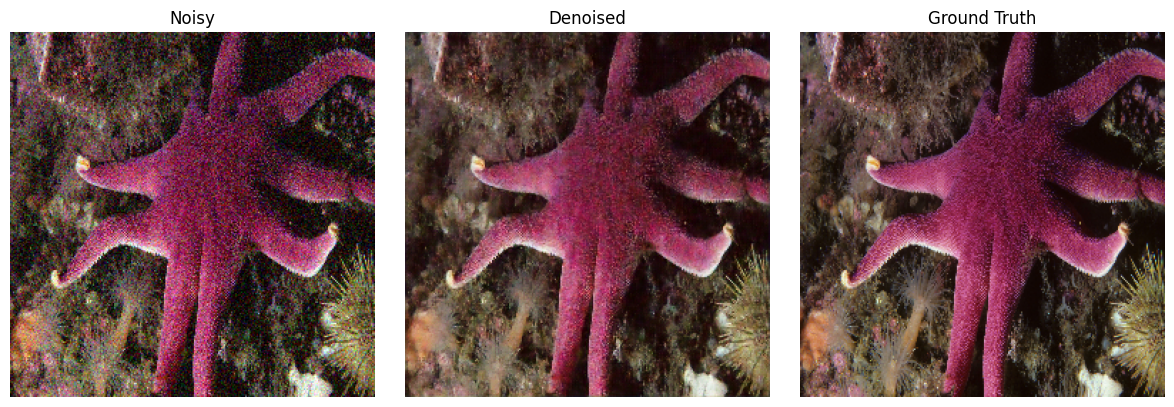

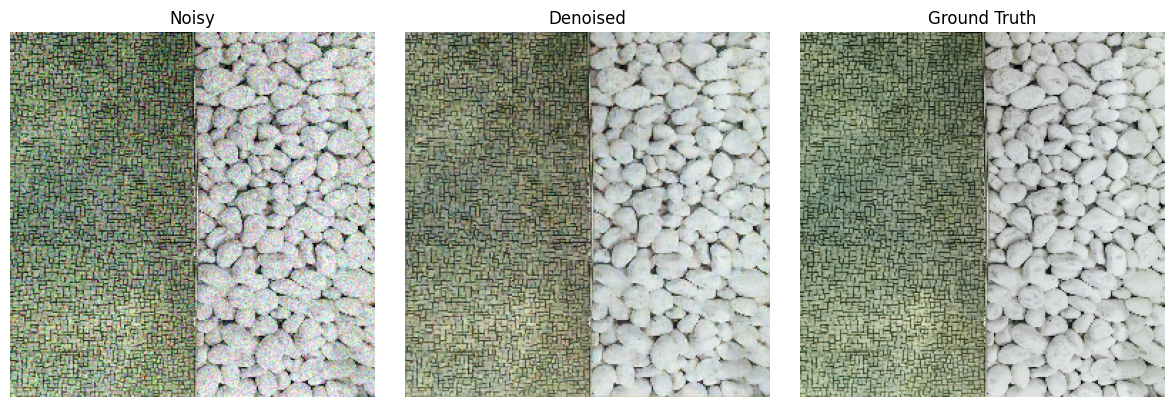

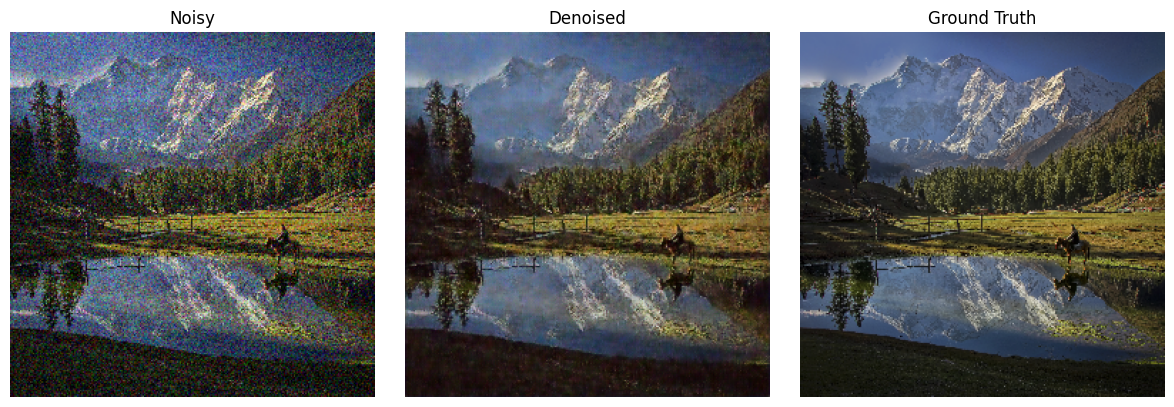

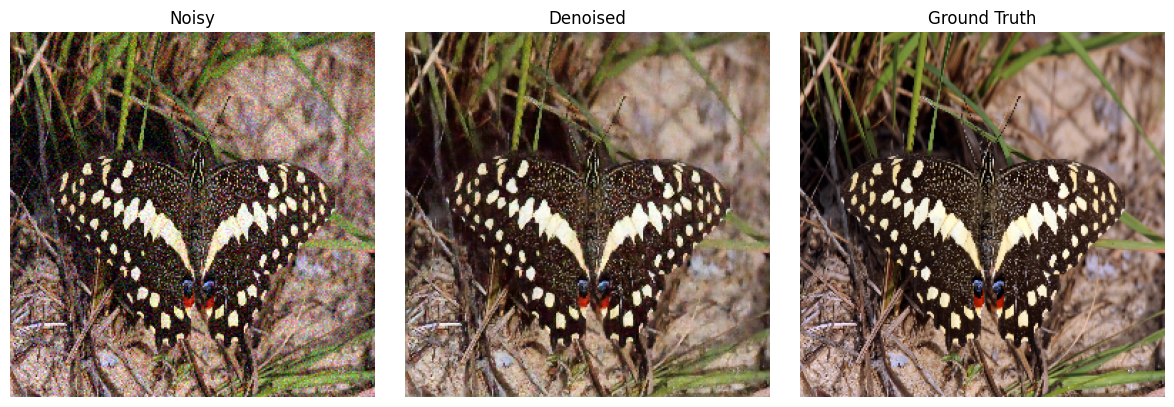

In [188]:
noisy_image, original_image = next(iter(train_dataloader))

denoised_image = denoise_image(model, noisy_image, device)
visualize_image(original_image, noisy_image, denoised_image)

### Evaluating metrics for UNET model

In [189]:
!pip install -q lpips

In [190]:
import math
import numpy as np
from math import log10, sqrt
from skimage.metrics import structural_similarity as ssim
import lpips
from torch.utils.data import DataLoader

def SNE(original, generated):
    diff = original - generated
    sne = (diff ** 2).sum()
    return sne

def evaluate_SNE(model: nn.Module, data: DataLoader, device: str):
    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = modified_img.to(device), original_img.to(device)
            generated_img = model(modified_img)

            score = SNE(generated_img, original_img)

            total_score += score
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average SNE: {average_score:.6f}")
    return average_score

def PSNR(original, generated):
    mse = torch.mean((original - generated) ** 2)
    if(mse == 0):
        return float("inf")
    max_pixel = 1
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr


def evaluate_PSNR(model: nn.Module, data: DataLoader, device: str):
    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = modified_img.to(device), original_img.to(device)
            generated_img = model(modified_img)

            score = PSNR(generated_img, original_img)
            print(num_batches)
            total_score += score
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average PSNR: {average_score:.2f} dB")
    return average_score

def SSIM(original: torch.Tensor, generated: torch.Tensor) -> float:
    original_np = original.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
    generated_np = generated.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()

    score = ssim(original_np, generated_np, data_range=1.0, channel_axis=2)
    return float(score)



def evaluate_SSIM(model: torch.nn.Module, data: torch.utils.data.DataLoader, device: str) -> float:
    model.eval()
    total_score = 0.0
    num_images = 0

    for modified_img, original_img in data:
        modified_img = modified_img.to(device)
        original_img = original_img.to(device)
        generated_img = model(modified_img)

        for i in range(generated_img.size(0)):
            score = SSIM(generated_img[i], original_img[i])
            total_score += score
            num_images += 1

    average_score = total_score / max(num_images, 1)
    print(f"Average SSIM: {average_score:.4f}")
    return average_score


def evaluate_LPIPS(model: nn.Module, data: DataLoader, device: str):

    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = modified_img.to(device), original_img.to(device)
            generated_img = model(modified_img)

            LPIPS = lpips.LPIPS(net='vgg').to(device)
            score = (LPIPS(generated_img, original_img)).mean()
            print(score)
            total_score += score
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average LPIPS: {average_score:.4f}")
    return average_score


In [201]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [192]:
avg_psnr = evaluate_PSNR(model, valdiation_dataloader, device)
avg_sne = evaluate_SNE(model, valdiation_dataloader, device)

0
1
2
3
4
5
6
Average PSNR: 7.88 dB
Average SNE: 727399.812500


In [200]:
torch.cuda.empty_cache()
avg_ssim = evaluate_SSIM(model, valdiation_dataloader, device)
torch.cuda.empty_cache()

OutOfMemoryError: CUDA out of memory. Tried to allocate 512.00 MiB. GPU 0 has a total capacity of 22.16 GiB of which 175.38 MiB is free. Process 32060 has 21.98 GiB memory in use. Of the allocated memory 20.96 GiB is allocated by PyTorch, and 819.92 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
avg_lpips = evaluate_LPIPS(model, valdiation_dataloader, device)

### Built in denoising method

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from skimage.restoration import denoise_bilateral


class DenoiseBilateral(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        device = x.device
        x_np = x.detach().cpu().numpy()  # shape (B, C, H, W)
        denoised_batch = []

        for img in x_np:
            img = np.moveaxis(img, 0, -1)  # (C, H, W) -> (H, W, C)
            denoised = denoise_bilateral(img, channel_axis=-1)
            denoised = np.moveaxis(denoised, -1, 0)  # back to (C, H, W)
            denoised_batch.append(denoised)

        denoised_batch = np.stack(denoised_batch, axis=0)  # (B, C, H, W)
        return torch.tensor(denoised_batch, dtype=torch.float32, device=device)

### Comparison of UNET model to denoise bilateral method from skimage

In [ ]:
noisy_image, original_image = next(iter(train_dataloader))

In [ ]:
BilateralDenoiser = DenoiseBilateral().to(device)

denoised_images_with_bilateral = denoise_image(BilateralDenoiser, noisy_image, device)
denoised_images_with_model = denoise_image(model, noisy_image, device)

In [ ]:
def compare_images(original, noisy, denoised_bilateral, denoised_model, n=4):

    original = original.permute(0, 2, 3, 1).cpu()
    noisy    = noisy.permute(0, 2, 3, 1).cpu()
    denoised_model = denoised_model.permute(0, 2, 3, 1).cpu()
    denoised_bilateral = denoised_bilateral.permute(0, 2, 3, 1).cpu()

    k = min(n, len(original), len(noisy), len(denoised_bilateral))
    for i in range(k):
        fig, axes = plt.subplots(1, 4, figsize=(12, 4))
        axes[0].imshow(noisy[i].clip(0, 1).squeeze())
        axes[0].set_title("Noisy")
        axes[0].axis("off")

        axes[1].imshow(denoised_model[i].clip(0, 1).squeeze())
        axes[1].set_title("Denoised with UNET")
        axes[1].axis("off")

        axes[2].imshow(denoised_bilateral[i].clip(0, 1).squeeze())
        axes[2].set_title("Denoised with bilateral")
        axes[2].axis("off")

        axes[3].imshow(original[i].clip(0, 1).squeeze())
        axes[3].set_title("Ground Truth")
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()


In [ ]:
compare_images(original_image, noisy_image, denoised_images_with_bilateral, denoised_images_with_model)

In [ ]:
avg_psnr_bilateral = evaluate_PSNR(BilateralDenoiser, valdiation_dataloader, device)
avg_sne_bilateral = evaluate_SNE(BilateralDenoiser, valdiation_dataloader, device)

In [ ]:
avg_ssim_bilateral = evaluate_SSIM(BilateralDenoiser, valdiation_dataloader, device)
torch.cuda.empty_cache()

In [ ]:
avg_lpips_bilateral = evaluate_LPIPS(BilateralDenoiser, valdiation_dataloader, device)

Denoise bilateral vs UNET metrics

In [ ]:
print("Compare Bilateral Denoiser vs UNET net")
print("PSNR")
print(f"Bilateral denoiser: {avg_psnr_bilateral:.2f}dB || UNET: {avg_psnr:.2f}dB")

In [ ]:
print("SNE")
print(f"Bilateral denoiser: {avg_sne_bilateral:.2f} || UNET: {avg_sne:.2f}")

In [ ]:
print("SSIM")
print(f"Bilateral denoiser: {avg_ssim_bilateral:.2f} || UNET: {avg_ssim:.2f}")

In [ ]:
print("LPIPS")
print(f"Bilateral denoiser: {avg_lpips_bilateral:.2f} || UNET: {avg_lpips:.2f}")